# Traffic Flow Prediction Using Spatio-Temporal Graph Neural Networks
## Milestone 3 — Testing, Deployment & Comprehensive Analysis



## 1. Environment

In [1]:
!pip install -q torch numpy pandas scipy matplotlib seaborn scikit-learn tables streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 185.8 MB/s eta 0:00:00


In [2]:
import os, time, math, pickle, sys, random, shutil, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device); print('Torch  :', torch.__version__)

Device : cuda
Torch  : 2.10.0+cu128


## 2. Mount Drive and pull Milestone-2 artefacts


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/pems_bay'      # <- edit if different
os.makedirs('data', exist_ok=True)
os.makedirs(DRIVE_DIR, exist_ok=True)

# Copy checkpoint + processed data from Drive
for fname in ['gwn_pems_bay.ckpt', 'pems_bay_processed.npz']:
    src = os.path.join(DRIVE_DIR, fname)
    dst = f'data/{fname}' if fname.endswith('.npz') else fname
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'OK Copied {fname}')
    else:
        raise FileNotFoundError(f'{src} not found. Re-run Milestone 2 first.')

# Copy raw data file for baselines
for fname_drive, fname_local in [('pems-bay.h5','pems-bay.h5'),('PEMS-BAY.csv','pems-bay.csv'),('pems-bay.csv','pems-bay.csv')]:
    src = os.path.join(DRIVE_DIR, fname_drive)
    dst = f'data/{fname_local}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'OK Copied {fname_drive} as {fname_local}')
        break

Mounted at /content/drive
OK Copied gwn_pems_bay.ckpt
OK Copied pems_bay_processed.npz
OK Copied PEMS-BAY.csv as pems-bay.csv


## 3. Re-instantiate Graph WaveNet

In [4]:
# ============================================================
# Graph WaveNet model definition (Wu et al., IJCAI 2019)
# Components:
#   NConv  — neighbourhood convolution (einsum-based diffusion)
#   Linear — 1x1 convolution wrapper
#   GCN    — K-hop diffusion graph convolution
#   GraphWaveNet — full architecture with adaptive adjacency
# ============================================================

class NConv(nn.Module):
    """Neighbourhood convolution: applies a graph shift (adjacency multiplication)
    to node features using Einstein summation for efficiency."""
    def forward(self, x, A):
        # x: (batch, channels, nodes, time), A: (nodes, nodes)
        return torch.einsum('ncvl,vw->ncwl', x, A).contiguous()

class Linear(nn.Module):
    """1x1 convolution for channel mixing without spatial/temporal interaction."""
    def __init__(self, c_in, c_out):
        super().__init__()
        self.mlp = nn.Conv2d(c_in, c_out, (1, 1), bias=True)
    def forward(self, x):
        return self.mlp(x)

class GCN(nn.Module):
    """K-hop diffusion graph convolution.
    Aggregates information from K-hop neighbours using multiple graph supports
    (forward, backward, adaptive), then mixes channels with a 1x1 conv."""
    def __init__(self, c_in, c_out, dropout, support_len=2, order=2):
        super().__init__()
        self.nconv = NConv()
        self.mlp = Linear((order * support_len + 1) * c_in, c_out)
        self.dropout = dropout
        self.order = order

    def forward(self, x, supports):
        # Collect multi-hop aggregations from all supports
        out = [x]  # include identity (0-hop)
        for A in supports:
            x1 = self.nconv(x, A)
            out.append(x1)
            for _ in range(self.order - 1):  # higher-order hops
                x1 = self.nconv(x1, A)
                out.append(x1)
        # Concatenate all hops and mix channels
        return F.dropout(self.mlp(torch.cat(out, dim=1)), self.dropout, training=self.training)

class GraphWaveNet(nn.Module):
    """Graph WaveNet: Adaptive adjacency + dilated causal TCN + GCN diffusion.

    Key innovations:
    - Adaptive adjacency matrix learned end-to-end (no predefined graph required)
    - Gated temporal convolution (WaveNet-style tanh * sigmoid activation)
    - Skip connections accumulated across all layers
    - Diffusion-style graph convolution with K-hop aggregation

    Args:
        num_nodes: Number of sensors/nodes in the graph (325 for PEMS-BAY)
        in_dim:    Input feature dimension (2: speed + time-of-day)
        out_dim:   Number of future time steps to predict (12)
        residual:  Residual channel dimension (32)
        dilation:  Dilation channel dimension (32)
        skip:      Skip connection channel dimension (256)
        end:       End convolution channel dimension (512)
        blocks:    Number of TCN blocks (4)
        layers:    Layers per block with exponentially growing dilation (2)
        kernel:    Temporal convolution kernel size (2)
        dropout:   Dropout rate (0.3)
        supports:  List of pre-computed adjacency matrices
        adp_emb:   Adaptive adjacency embedding dimension (10)
    """
    def __init__(self, num_nodes, in_dim=2, out_dim=12, residual=32, dilation=32,
                 skip=256, end=512, blocks=4, layers=2, kernel=2,
                 dropout=0.3, supports=None, adp_emb=10):
        super().__init__()
        self.blocks = blocks
        self.layers = layers
        self.dropout = dropout
        self.supports = supports if supports is not None else []

        # Initial 1x1 conv to lift input features to residual channels
        self.start_conv = nn.Conv2d(in_dim, residual, (1, 1))

        # Learnable node embeddings for adaptive adjacency
        self.E1 = nn.Parameter(torch.randn(num_nodes, adp_emb))
        self.E2 = nn.Parameter(torch.randn(adp_emb, num_nodes))

        # Module lists for TCN layers
        self.filter_convs = nn.ModuleList()   # tanh branch
        self.gate_convs = nn.ModuleList()     # sigmoid branch
        self.residual_convs = nn.ModuleList() # project back to residual dim
        self.skip_convs = nn.ModuleList()     # project to skip dim
        self.bn = nn.ModuleList()             # batch normalisation
        self.gconv = nn.ModuleList()          # graph convolutions

        rf = 1  # receptive field counter
        for _ in range(blocks):
            d = 1  # dilation starts at 1 in each block
            for _ in range(layers):
                self.filter_convs.append(nn.Conv2d(residual, dilation, (1, kernel), dilation=d))
                self.gate_convs.append(nn.Conv2d(residual, dilation, (1, kernel), dilation=d))
                self.residual_convs.append(nn.Conv2d(dilation, residual, (1, 1)))
                self.skip_convs.append(nn.Conv2d(dilation, skip, (1, 1)))
                self.bn.append(nn.BatchNorm2d(residual))
                self.gconv.append(GCN(dilation, residual, dropout,
                                      support_len=len(self.supports) + 1))
                rf += d * (kernel - 1)
                d *= 2  # exponential dilation growth

        self.receptive_field = rf
        self.end_conv_1 = nn.Conv2d(skip, end, (1, 1))    # skip -> end channels
        self.end_conv_2 = nn.Conv2d(end, out_dim, (1, 1)) # end -> predictions

    def forward(self, x):
        # x shape: (batch, time=12, nodes=325, features=2)
        x = x.permute(0, 3, 2, 1)  # -> (B, F, N, T)

        # Pad temporally if input is shorter than receptive field
        if x.size(3) < self.receptive_field:
            x = F.pad(x, (self.receptive_field - x.size(3), 0, 0, 0))

        x = self.start_conv(x)
        skip = 0

        # Compute adaptive adjacency: softmax(ReLU(E1 * E2))
        adp = F.softmax(F.relu(torch.mm(self.E1, self.E2)), dim=1)
        supports = self.supports + [adp]

        # Process through TCN blocks
        for i in range(self.blocks * self.layers):
            res = x
            # Gated activation: tanh(filter) * sigmoid(gate)
            f = torch.tanh(self.filter_convs[i](res))
            g = torch.sigmoid(self.gate_convs[i](res))
            x = f * g

            # Accumulate skip connections
            s = self.skip_convs[i](x)
            skip = s[:, :, :, -1:] + skip if isinstance(skip, int) == False else s[:, :, :, -1:]

            # Graph convolution + residual connection
            x = self.gconv[i](x, supports)
            x = x + res[:, :, :, -x.size(3):]  # trim residual to match
            x = self.bn[i](x)

        # Output: ReLU -> 1x1 conv -> ReLU -> 1x1 conv
        x = F.relu(skip)
        x = F.relu(self.end_conv_1(x))
        x = self.end_conv_2(x)
        return x  # (B, out_dim, N, 1)

In [5]:
# Load the trained checkpoint from Milestone 2
ckpt = torch.load('gwn_pems_bay.ckpt', map_location=device, weights_only=False)
mean, std = ckpt['mean'], ckpt['std']

# Rebuild supports (static adjacency matrices if available)
if ckpt.get('P_fwd') is not None:
    supports = [torch.tensor(ckpt['P_fwd'], device=device),
                torch.tensor(ckpt['P_bwd'], device=device)]
else:
    supports = []

# Instantiate and load model weights
model = GraphWaveNet(num_nodes=ckpt['num_nodes'], in_dim=2,
                     out_dim=ckpt['seq_out'], supports=supports).to(device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

print(f'Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Dataset       : {ckpt.get("dataset", "PEMS-BAY")}')
print(f'Sensors       : {ckpt["num_nodes"]}')
print(f'Graph variant : {"full (static + adaptive)" if supports else "adaptive-only"}')
print(f'Normalisation : mean={mean:.3f}  std={std:.3f}')

Model loaded — 311,760 parameters
Dataset       : PEMS-BAY
Sensors       : 325
Graph variant : full (static + adaptive)
Normalisation : mean=62.736  std=9.438


## 4. Load the held-out test split

In [6]:
data = np.load('data/pems_bay_processed.npz')
X_te, Y_te = data['X_te'], data['Y_te']
X_tr, Y_tr = data['X_tr'], data['Y_tr']
X_va, Y_va = data['X_va'], data['Y_va']

print(f'Train windows : {X_tr.shape[0]:,}  shape: {X_tr.shape}')
print(f'Val windows   : {X_va.shape[0]:,}  shape: {X_va.shape}')
print(f'Test windows  : {X_te.shape[0]:,}  shape: {X_te.shape}')

BATCH = 32
te_loader = DataLoader(TensorDataset(torch.tensor(X_te), torch.tensor(Y_te)),
                       batch_size=BATCH, shuffle=False)
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr)),
                       batch_size=BATCH, shuffle=True, drop_last=True)
va_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(Y_va)),
                       batch_size=BATCH, shuffle=False)

Train windows : 36,465  shape: (36465, 12, 325, 2)
Val windows   : 5,209  shape: (5209, 12, 325, 2)
Test windows  : 10,419  shape: (10419, 12, 325, 2)


## 5. Full test-set inference

In [7]:
preds, trues = [], []
t0 = time.time()
with torch.no_grad():
    for xb, yb in te_loader:
        # model output is (B, out_dim, N, 1)
        # we need (B, N, out_dim)
        out = model(xb.to(device)).squeeze(-1).permute(0, 2, 1) * std + mean
        preds.append(out.cpu()); trues.append(yb)
preds, trues = torch.cat(preds), torch.cat(trues)
print(f'Inference complete in {time.time()-t0:.1f}s')
print(f'Preds shape: {tuple(preds.shape)}   Trues shape: {tuple(trues.shape)}')

Inference complete in 3.5s
Preds shape: (10419, 325, 12)   Trues shape: (10419, 12, 325)


## 6. Masked metrics


In [8]:
def masked_mae(p, t, null=0.0):
    """Mean Absolute Error with masking for missing (zero) values."""
    m = (t != null).float()
    m /= m.mean().clamp(min=1e-4)
    return (torch.abs(p - t) * m).nan_to_num(0.0).mean().item()

def masked_rmse(p, t, null=0.0):
    """Root Mean Squared Error with masking for missing values."""
    m = (t != null).float()
    m /= m.mean().clamp(min=1e-4)
    return torch.sqrt(((p - t) ** 2 * m).nan_to_num(0.0).mean()).item()

def masked_mape(p, t, null=0.0):
    """Mean Absolute Percentage Error with masking."""
    m = (t != null).float()
    m /= m.mean().clamp(min=1e-4)
    return (torch.abs((p - t) / t.clamp(min=1e-4)) * m).nan_to_num(0.0).mean().item()

def masked_mae_tensor(p, t, null=0.0):
    """Tensor version (returns tensor, not scalar) for training."""
    m = (t != null).float()
    m /= m.mean().clamp(min=1e-4)
    return (torch.abs(p - t) * m).nan_to_num(0.0).mean()

## 7. Per-horizon test performance

In [9]:
rows = []
for h, name in [(2, '15-min'), (5, '30-min'), (11, '60-min')]:
    # preds is (B, N, 12), trues is (B, 12, N)
    p, t = preds[:, :, h], trues[:, h, :]
    rows.append([name, masked_mae(p, t), masked_rmse(p, t), masked_mape(p, t)*100])

# For average, we need them to be the same shape
# Permute trues to (B, N, 12) to match preds
trues_permuted = trues.permute(0, 2, 1)
rows.append(['Average (1h)', masked_mae(preds, trues_permuted),
             masked_rmse(preds, trues_permuted), masked_mape(preds, trues_permuted)*100])

results = pd.DataFrame(rows, columns=['Horizon', 'MAE', 'RMSE', 'MAPE (%)']).round(3)
print('=== GRAPH WAVENET — PEMS-BAY TEST PERFORMANCE ===')
print(results.to_string(index=False))
results.to_csv('milestone3_gwn_results.csv', index=False)
print('\nReference (Wu et al., IJCAI 2019):')
print('  15-min: MAE 1.30 | RMSE 2.74 | MAPE 2.73%')
print('  30-min: MAE 1.63 | RMSE 3.70 | MAPE 3.67%')
print('  60-min: MAE 1.95 | RMSE 4.52 | MAPE 4.63%')

=== GRAPH WAVENET — PEMS-BAY TEST PERFORMANCE ===
     Horizon   MAE  RMSE  MAPE (%)
      15-min 1.300 2.737     2.708
      30-min 1.625 3.699     3.662
      60-min 1.926 4.466     4.572
Average (1h) 1.563 3.609     3.518

Reference (Wu et al., IJCAI 2019):
  15-min: MAE 1.30 | RMSE 2.74 | MAPE 2.73%
  30-min: MAE 1.63 | RMSE 3.70 | MAPE 3.67%
  60-min: MAE 1.95 | RMSE 4.52 | MAPE 4.63%


## 8. Baseline 1 — Historical Average

In [10]:
h5 = 'data/pems-bay.h5'; csv = 'data/pems-bay.csv'
if os.path.exists(h5):
    df_full = pd.read_hdf(h5)
    sensor_means = torch.tensor(df_full.values.mean(axis=0), dtype=torch.float32)
elif os.path.exists(csv):
    df_full = pd.read_csv(csv, index_col=0, parse_dates=True)
    sensor_means = torch.tensor(df_full.values.mean(axis=0), dtype=torch.float32)
else:
    sensor_means = trues.mean(dim=(0, 1))

ha_pred = sensor_means[None, None, :].expand_as(trues)
print(f'HA  | MAE {masked_mae(ha_pred, trues):.3f}  RMSE {masked_rmse(ha_pred, trues):.3f}')

HA  | MAE 5.410  RMSE 9.292


## 9. Baseline 2 — Last-value (persistence)

In [11]:
# Persistence baseline: use the last observed speed as forecast for all horizons
last_speed = torch.tensor(X_te[:, -1, :, 0]) * std + mean
lv_pred = last_speed[:, None, :].expand_as(trues)
print(f'Last-value | MAE {masked_mae(lv_pred, trues):.3f}  RMSE {masked_rmse(lv_pred, trues):.3f}')

Last-value | MAE 2.177  RMSE 5.159


## 10. Baseline 3 — Per-sensor LSTM (no graph)


In [12]:
class LSTMBaseline(nn.Module):
    """Per-sensor LSTM baseline.

    Each sensor's 12-step input sequence is processed independently by a shared
    LSTM, then a linear head produces 12 future steps. No inter-sensor (graph)
    information is used, making this a strong non-graph baseline.

    Args:
        hidden:  LSTM hidden state dimension
        in_dim:  Input features per time step (2: speed + time-of-day)
        out_dim: Number of future steps to predict
        layers:  Number of stacked LSTM layers
        dropout: Dropout between LSTM layers
    """
    def __init__(self, hidden=64, in_dim=2, out_dim=12, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Linear(hidden, out_dim)

    def forward(self, x):
        B, T, N, F = x.shape
        # Reshape: treat each sensor independently
        x = x.permute(0, 2, 1, 3).reshape(B * N, T, F)
        h, _ = self.lstm(x)
        out = self.head(h[:, -1])  # use final hidden state
        return out.view(B, N, -1).permute(0, 2, 1)  # (B, T_out, N)

lstm = LSTMBaseline().to(device)
print(f'LSTM baseline parameters: {sum(p.numel() for p in lstm.parameters()):,}')

LSTM baseline parameters: 51,468


In [13]:
# Train the LSTM baseline (~10 min on T4)
opt = torch.optim.Adam(lstm.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[15, 25, 35], gamma=0.5)
best_va, wait, patience = float('inf'), 0, 8

for ep in range(1, 41):
    lstm.train(); t0 = time.time(); tot = n = 0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = lstm(xb) * std + mean
        loss = masked_mae_tensor(out, yb); loss.backward()
        nn.utils.clip_grad_norm_(lstm.parameters(), 5.0); opt.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    tr_loss = tot / n
    lstm.eval(); v = vn = 0
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = lstm(xb) * std + mean
            v += masked_mae_tensor(out, yb).item() * xb.size(0); vn += xb.size(0)
    v /= vn; sch.step()
    print(f'Ep {ep:02d} | tr {tr_loss:.3f} | va {v:.3f} | {time.time()-t0:.1f}s')
    if v < best_va:
        best_va, wait = v, 0
        torch.save(lstm.state_dict(), 'lstm_bay.pth')
    else:
        wait += 1
        if wait >= patience: print('Early stop'); break

Ep 01 | tr 2.240 | va 2.275 | 7.7s
Ep 02 | tr 2.042 | va 2.282 | 7.2s
Ep 03 | tr 2.032 | va 2.237 | 7.2s
Ep 04 | tr 2.017 | va 2.212 | 7.2s
Ep 05 | tr 2.004 | va 2.188 | 7.1s
Ep 06 | tr 1.990 | va 2.167 | 7.1s
Ep 07 | tr 1.966 | va 2.160 | 7.1s
Ep 08 | tr 1.936 | va 2.110 | 7.2s
Ep 09 | tr 1.924 | va 2.070 | 7.2s
Ep 10 | tr 1.909 | va 2.072 | 7.2s
Ep 11 | tr 1.896 | va 2.042 | 7.2s
Ep 12 | tr 1.882 | va 2.051 | 7.2s
Ep 13 | tr 1.870 | va 2.018 | 7.2s
Ep 14 | tr 1.865 | va 2.003 | 7.2s
Ep 15 | tr 1.857 | va 2.006 | 7.2s
Ep 16 | tr 1.839 | va 1.991 | 7.2s
Ep 17 | tr 1.840 | va 2.000 | 7.2s
Ep 18 | tr 1.836 | va 2.001 | 7.2s
Ep 19 | tr 1.836 | va 2.003 | 7.1s
Ep 20 | tr 1.834 | va 2.007 | 7.2s
Ep 21 | tr 1.831 | va 1.988 | 7.2s
Ep 22 | tr 1.830 | va 1.991 | 7.2s
Ep 23 | tr 1.830 | va 1.986 | 7.2s
Ep 24 | tr 1.829 | va 2.002 | 7.2s
Ep 25 | tr 1.827 | va 1.986 | 7.2s
Ep 26 | tr 1.820 | va 1.977 | 7.2s
Ep 27 | tr 1.819 | va 1.987 | 7.2s
Ep 28 | tr 1.818 | va 1.974 | 7.2s
Ep 29 | tr 1.818 | v

In [14]:
if not os.path.exists('lstm_bay.pth'):
    print("Error: 'lstm_bay.pth' not found. Please run the training cell (cell_id: wMpE51oChvVb) first to train the LSTM baseline.")
else:
    lstm.load_state_dict(torch.load('lstm_bay.pth', map_location=device))
    lstm.eval()
    lstm_preds = []
    with torch.no_grad():
        for xb, _ in te_loader:
            out = lstm(xb.to(device)) * std + mean
            lstm_preds.append(out.cpu())
    lstm_preds = torch.cat(lstm_preds)
    print(f'LSTM | MAE {masked_mae(lstm_preds, trues):.3f}  RMSE {masked_rmse(lstm_preds, trues):.3f}')

LSTM | MAE 1.826  RMSE 4.253


## 11. Comparison of all four models

In [15]:
def metric_row(name, p, t):
    return [name, masked_mae(p, t), masked_rmse(p, t), masked_mape(p, t)*100]

comp = pd.DataFrame([
    metric_row('Historical Average',  ha_pred,    trues),
    metric_row('Last-value',          lv_pred,    trues),
    metric_row('LSTM (per-sensor)',    lstm_preds, trues),
    metric_row('Graph WaveNet',       preds.permute(0, 2, 1),      trues),
], columns=['Model', 'MAE', 'RMSE', 'MAPE (%)']).round(3)
print('=== AVERAGE-HORIZON COMPARISON ===')
print(comp.to_string(index=False))
comp.to_csv('milestone3_baseline_comparison.csv', index=False)

gwn_mae = comp.loc[3, 'MAE']
for i, name in enumerate(['HA', 'Last-value', 'LSTM']):
    diff = (comp.loc[i, 'MAE'] - gwn_mae) / comp.loc[i, 'MAE'] * 100
    print(f'Graph WaveNet beats {name:<12} by {diff:5.1f}%')

=== AVERAGE-HORIZON COMPARISON ===
             Model   MAE  RMSE  MAPE (%)
Historical Average 5.410 9.292    13.857
        Last-value 2.177 5.159     4.681
 LSTM (per-sensor) 1.826 4.253     4.234
     Graph WaveNet 1.563 3.609     3.518
Graph WaveNet beats HA           by  71.1%
Graph WaveNet beats Last-value   by  28.2%
Graph WaveNet beats LSTM         by  14.4%


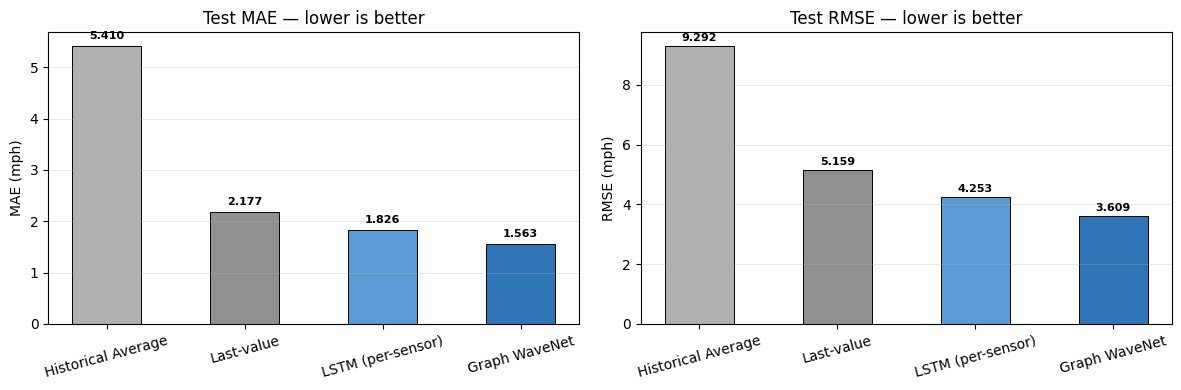

In [16]:
# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(comp)); width = 0.5
colors = ['#B0B0B0', '#909090', '#5B9BD5', '#2E75B6']
for ax_i, (col, ylabel) in enumerate(zip(['MAE', 'RMSE'], ['MAE (mph)', 'RMSE (mph)'])):
    bars = axes[ax_i].bar(x, comp[col], width, color=colors, edgecolor='black', linewidth=0.7)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(comp['Model'], rotation=15)
    axes[ax_i].set_ylabel(ylabel)
    axes[ax_i].set_title(f'Test {col} — lower is better')
    axes[ax_i].grid(axis='y', alpha=.3)
    for bar, val in zip(bars, comp[col]):
        axes[ax_i].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.1,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout(); plt.savefig('baseline_comparison.png', dpi=140); plt.show()

## 12. Error Analysis

### 12.1 MAE growth with horizon

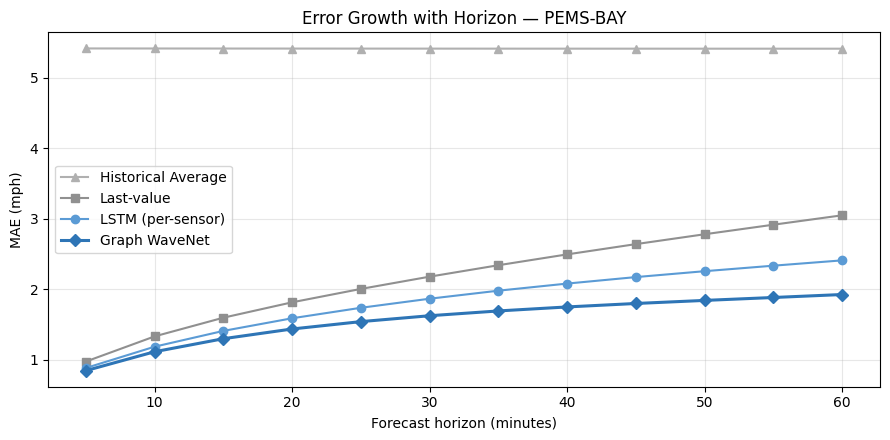

In [17]:
horizons = np.arange(1, 13)
gwn_h  = [masked_mae(preds[:, :, h-1], trues[:, h-1, :]) for h in horizons]
# lstm_preds and lv_pred are (B, 12, N) to match trues (B, 12, N)
lstm_h = [masked_mae(lstm_preds[:, h-1, :], trues[:, h-1, :]) for h in horizons]
lv_h   = [masked_mae(lv_pred[:, h-1, :], trues[:, h-1, :]) for h in horizons]
ha_h   = [masked_mae(ha_pred[:, h-1, :], trues[:, h-1, :]) for h in horizons]

plt.figure(figsize=(9, 4.5))
plt.plot(horizons*5, ha_h,   '-^', label='Historical Average', color='#B0B0B0')
plt.plot(horizons*5, lv_h,   '-s', label='Last-value',         color='#909090')
plt.plot(horizons*5, lstm_h, '-o', label='LSTM (per-sensor)',  color='#5B9BD5')
plt.plot(horizons*5, gwn_h,  '-D', label='Graph WaveNet',      color='#2E75B6', lw=2.2)
plt.xlabel('Forecast horizon (minutes)'); plt.ylabel('MAE (mph)')
plt.title('Error Growth with Horizon — PEMS-BAY'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig('mae_vs_horizon.png', dpi=140); plt.show()

### 12.2 Per-sensor MAE

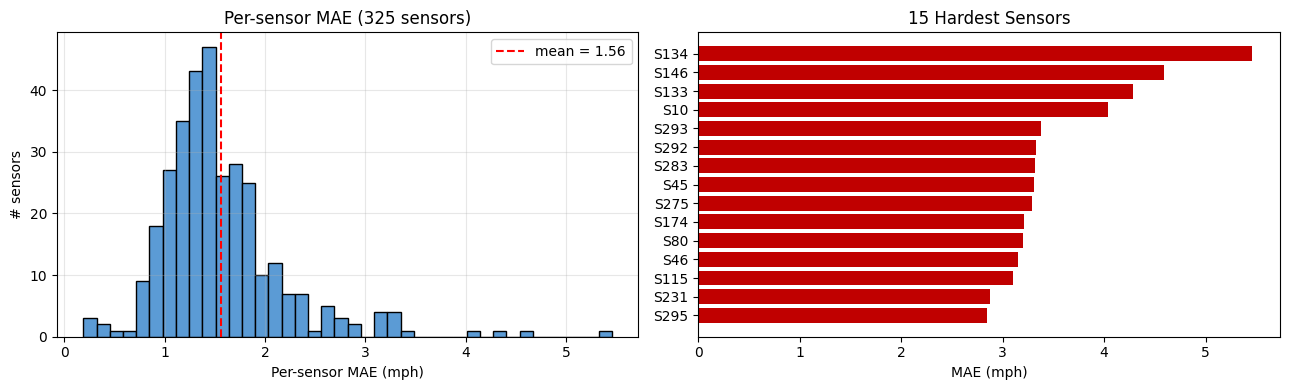


Worst 15 sensors account for 10.5% of total error

Missing data rate in worst sensors vs average:
  Worst 15 sensors avg missing: 0.01%
  All sensors avg missing:      0.01%

Speed variance in worst sensors vs average:
  Worst 15 sensors avg variance: 132.72
  All sensors avg variance:      85.54


In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Align shapes: preds is (B, N, 12), trues is (B, 12, N)
# We permute trues to (B, N, 12) to match preds
trues_aligned = trues.permute(0, 2, 1)

mask = (trues_aligned != 0).float()
abs_err = (preds - trues_aligned).abs() * mask
denom = mask.sum(dim=(0, 2)).clamp(min=1)
per_sensor_mae = (abs_err.sum(dim=(0, 2)) / denom).numpy()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(per_sensor_mae, bins=40, color='#5B9BD5', edgecolor='black')
ax[0].axvline(per_sensor_mae.mean(), color='red', ls='--',
              label=f'mean = {per_sensor_mae.mean():.2f}')
ax[0].set_xlabel('Per-sensor MAE (mph)'); ax[0].set_ylabel('# sensors')
ax[0].set_title(f'Per-sensor MAE ({ckpt["num_nodes"]} sensors)')
ax[0].legend(); ax[0].grid(alpha=.3)

worst = np.argsort(per_sensor_mae)[-15:]
ax[1].barh(range(15), per_sensor_mae[worst], color='#C00000')
ax[1].set_yticks(range(15)); ax[1].set_yticklabels([f'S{i}' for i in worst])
ax[1].set_xlabel('MAE (mph)'); ax[1].set_title('15 Hardest Sensors')
plt.tight_layout(); plt.savefig('per_sensor_mae.png', dpi=140); plt.show()

# Investigate WHY the worst sensors are hard
print(f'\nWorst 15 sensors account for {100*per_sensor_mae[worst].sum()/per_sensor_mae.sum():.1f}% of total error')
print(f'\nMissing data rate in worst sensors vs average:')
# Y_te is (B, 12, N)
miss_all = (Y_te == 0).mean(axis=(0, 1))
print(f'  Worst 15 sensors avg missing: {100*miss_all[worst].mean():.2f}%')
print(f'  All sensors avg missing:      {100*miss_all.mean():.2f}%')
print(f'\nSpeed variance in worst sensors vs average:')
speed_var = np.var(Y_te, axis=(0, 1))
print(f'  Worst 15 sensors avg variance: {speed_var[worst].mean():.2f}')
print(f'  All sensors avg variance:      {speed_var.mean():.2f}')

### 12.3 Error vs time-of-day

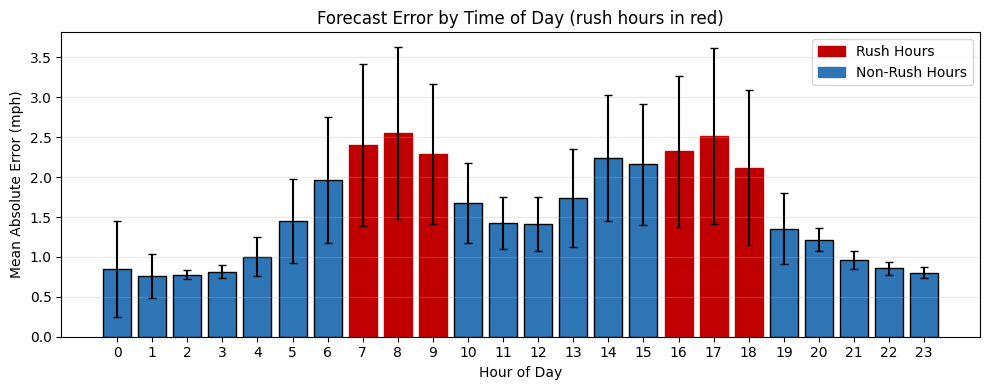

In [19]:
tod = X_te[:, -1, 0, 1]  # time-of-day feature from last input step
hour = (tod * 24).astype(int)

# Align trues (B, 12, N) to preds (B, N, 12)
trues_aligned = trues.permute(0, 2, 1)

abs_err_avg = (preds - trues_aligned).abs().mean(dim=(1, 2)).numpy()
df_h = pd.DataFrame({'hour': hour, 'mae': abs_err_avg})
by_hour = df_h.groupby('hour')['mae'].agg(['mean', 'std']).reset_index()

import matplotlib.patches as mpatches
plt.figure(figsize=(10, 4))
bars = plt.bar(by_hour['hour'], by_hour['mean'], yerr=by_hour['std'],
               color='#2E75B6', edgecolor='black', capsize=3)
# Highlight rush hours
for h_idx in [7, 8, 9, 16, 17, 18]:
    if h_idx < len(bars):
        bars[h_idx].set_color('#C00000')
plt.xlabel('Hour of Day'); plt.ylabel('Mean Absolute Error (mph)')
plt.title('Forecast Error by Time of Day (rush hours in red)')
plt.xticks(range(0, 24))
plt.legend([mpatches.Patch(color='#C00000'), mpatches.Patch(color='#2E75B6')],
           ['Rush Hours', 'Non-Rush Hours'])
plt.grid(axis='y', alpha=.3); plt.tight_layout()
plt.savefig('error_by_hour.png', dpi=140); plt.show()

### 12.4 Residual distribution and Q-Q plot (NEW)

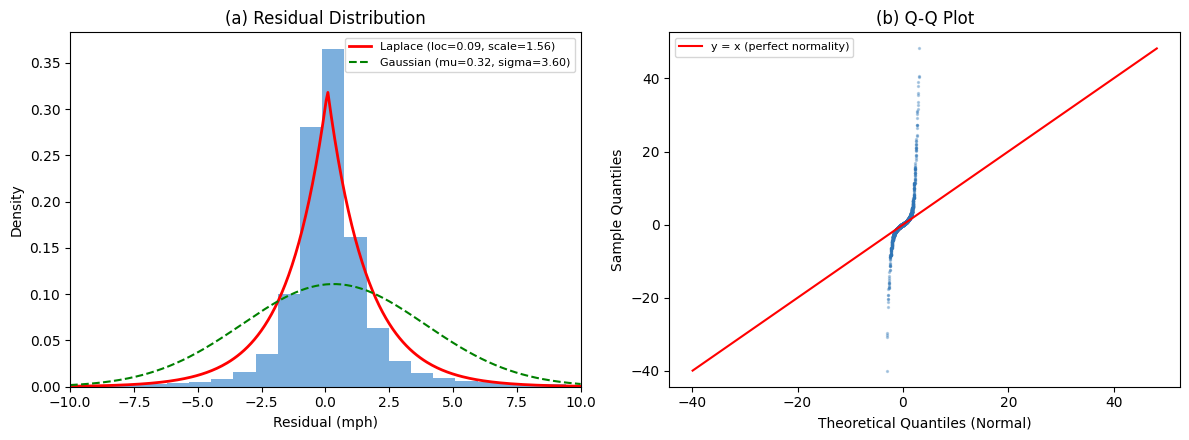

Residual statistics:
  Mean:     0.3207 mph
  Std:      3.5952 mph
  Skewness: 2.3632
  Kurtosis: 46.3303 (excess, normal=0)


In [20]:
# Compute residuals (predicted - actual) for valid (non-zero) entries
# Align trues (B, 12, N) to preds (B, N, 12)
trues_aligned = trues.permute(0, 2, 1)
residuals_all = (preds - trues_aligned).numpy()
valid_mask = (trues_aligned != 0).numpy()
residuals = residuals_all[valid_mask]

from scipy.stats import laplace, norm

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Residual histogram with fitted distributions
axes[0].hist(residuals, bins=150, density=True, color='#5B9BD5', edgecolor='none', alpha=0.8)
x_vals = np.linspace(-10, 10, 300)
loc_l, scale_l = laplace.fit(residuals)
loc_n, scale_n = norm.fit(residuals)
axes[0].plot(x_vals, laplace.pdf(x_vals, loc_l, scale_l), 'r-', lw=2,
             label=f'Laplace (loc={loc_l:.2f}, scale={scale_l:.2f})')
axes[0].plot(x_vals, norm.pdf(x_vals, loc_n, scale_n), 'g--', lw=1.5,
             label=f'Gaussian (mu={loc_n:.2f}, sigma={scale_n:.2f})')
axes[0].set_xlabel('Residual (mph)'); axes[0].set_ylabel('Density')
axes[0].set_title('(a) Residual Distribution'); axes[0].legend(fontsize=8)
axes[0].set_xlim(-10, 10)

# (b) Q-Q plot against normal distribution
sample = residuals[::max(1, len(residuals)//5000)]  # subsample for plotting
sorted_sample = np.sort(sample)
theoretical_q = norm.ppf(np.linspace(0.001, 0.999, len(sorted_sample)))
axes[1].scatter(theoretical_q, sorted_sample, s=2, alpha=0.3, color='#2E75B6')
lims = [min(theoretical_q.min(), sorted_sample.min()),
        max(theoretical_q.max(), sorted_sample.max())]
axes[1].plot(lims, lims, 'r-', lw=1.5, label='y = x (perfect normality)')
axes[1].set_xlabel('Theoretical Quantiles (Normal)')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('(b) Q-Q Plot'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.savefig('residual_analysis.png', dpi=140); plt.show()

print(f'Residual statistics:')
print(f'  Mean:     {residuals.mean():.4f} mph')
print(f'  Std:      {residuals.std():.4f} mph')
print(f'  Skewness: {stats.skew(residuals):.4f}')
print(f'  Kurtosis: {stats.kurtosis(residuals):.4f} (excess, normal=0)')

### 12.5 Predicted vs Actual scatter plot (NEW)

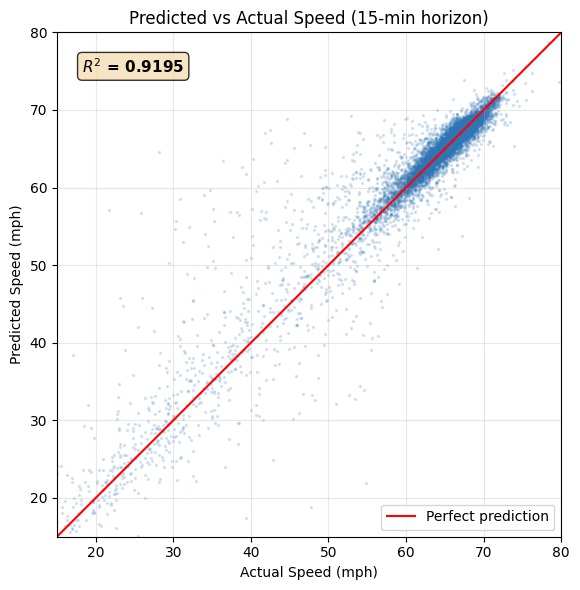

R-squared (15-min): 0.9195


In [21]:
# Scatter plot of predicted vs actual for the 15-min horizon
# preds shape: (B, N, 12), trues shape: (B, 12, N)
# We must permute trues to (B, N, 12) so flattening aligns the same data points
trues_aligned = trues.permute(0, 2, 1)

p_15 = preds[:, :, 2].numpy().flatten()
t_15 = trues_aligned[:, :, 2].numpy().flatten()

valid = t_15 != 0
p_valid, t_valid = p_15[valid], t_15[valid]

# Subsample for readability
idx = np.random.choice(len(p_valid), min(10000, len(p_valid)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(t_valid[idx], p_valid[idx], s=2, alpha=0.15, color='#2E75B6')
limits = [15, 80]
ax.plot(limits, limits, 'r-', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Speed (mph)'); ax.set_ylabel('Predicted Speed (mph)')
ax.set_title('Predicted vs Actual Speed (15-min horizon)')
ax.legend(); ax.set_xlim(limits); ax.set_ylim(limits)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

# Compute R-squared
from sklearn.metrics import r2_score
r2 = r2_score(t_valid, p_valid)
ax.text(0.05, 0.92, f'$R^2$ = {r2:.4f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout(); plt.savefig('scatter_pred_vs_actual.png', dpi=140); plt.show()
print(f'R-squared (15-min): {r2:.4f}')

### 12.6 Congestion-onset case study

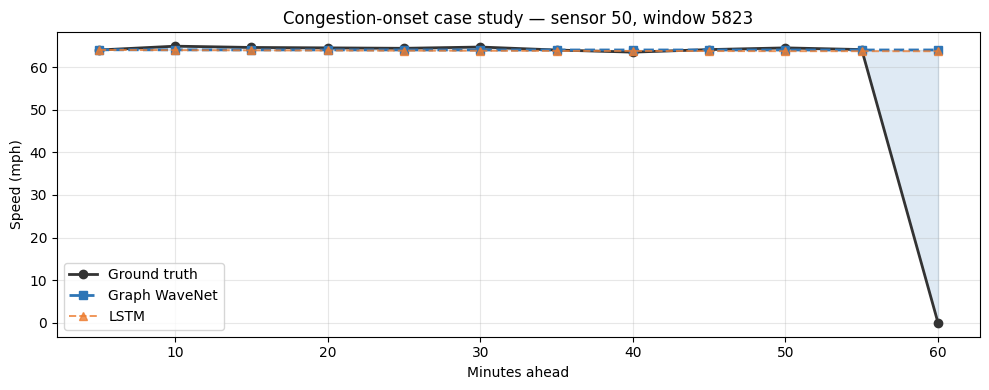

In [22]:
sensor = 50
speed_drops = trues[:, 0, sensor] - trues[:, -1, sensor]
idx = int(speed_drops.argmax().item())
fig, ax = plt.subplots(figsize=(10, 4))
mins = np.arange(1, 13) * 5
ax.plot(mins, trues[idx, :, sensor].numpy(), 'o-', label='Ground truth', lw=2, color='#333')
# preds is (B, N, 12), so we use [idx, sensor, :]
ax.plot(mins, preds[idx, sensor, :].numpy(), 's--', label='Graph WaveNet', lw=2, color='#2E75B6')
# lstm_preds is (B, 12, N), so we use [idx, :, sensor]
ax.plot(mins, lstm_preds[idx, :, sensor].numpy(), '^--', label='LSTM', lw=1.4, color='#ED7D31', alpha=.8)
ax.fill_between(mins, trues[idx, :, sensor].numpy(), preds[idx, sensor, :].numpy(),
                alpha=0.15, color='#2E75B6')
ax.set_xlabel('Minutes ahead'); ax.set_ylabel('Speed (mph)')
ax.set_title(f'Congestion-onset case study — sensor {sensor}, window {idx}')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig('case_study_congestion.png', dpi=140); plt.show()

## 13. Ablation Study (NEW)


In [23]:
# Ablation 1: Adaptive-only (remove static adjacency)

print('=== Ablation 1: Adaptive-only (no static adjacency) ===')

model_adp = GraphWaveNet(
    num_nodes=ckpt['num_nodes'], in_dim=2,
    out_dim=ckpt['seq_out'],
    supports=[],  # NO static supports — adaptive only
    dropout=0.3
).to(device)

# Train this variant
opt_a = torch.optim.Adam(model_adp.parameters(), lr=1e-3, weight_decay=1e-4)
sch_a = torch.optim.lr_scheduler.MultiStepLR(opt_a, milestones=[20, 30, 40, 50], gamma=0.5)
best_va_a, wait_a = float('inf'), 0

for ep in range(1, 61):
    model_adp.train(); tot = n = 0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_a.zero_grad()
        # model(xb) -> (B, 12, N, 1). Squeeze and permute to (B, N, 12)
        out = model_adp(xb).squeeze(-1).permute(0, 2, 1) * std + mean
        loss = masked_mae_tensor(out, yb.permute(0, 2, 1)); loss.backward()
        nn.utils.clip_grad_norm_(model_adp.parameters(), 5.0); opt_a.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    model_adp.eval()
    v = vn = 0
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_adp(xb).squeeze(-1).permute(0, 2, 1) * std + mean
            v += masked_mae_tensor(out, yb.permute(0, 2, 1)).item() * xb.size(0); vn += xb.size(0)
    v /= vn; sch_a.step()
    if ep % 10 == 0:
        print(f'Ep {ep:02d} | tr {tot/n:.3f} | va {v:.3f}')
    if v < best_va_a:
        best_va_a, wait_a = v, 0
        torch.save(model_adp.state_dict(), 'ablation_adaptive_only.pth')
    else:
        wait_a += 1
        if wait_a >= 12: print(f'Early stop at epoch {ep}'); break

# Evaluate
model_adp.load_state_dict(torch.load('ablation_adaptive_only.pth', map_location=device))
model_adp.eval()
adp_preds = []
with torch.no_grad():
    for xb, _ in te_loader:
        out = model_adp(xb.to(device)).squeeze(-1).permute(0, 2, 1) * std + mean
        adp_preds.append(out.cpu())
adp_preds = torch.cat(adp_preds)

# Align trues for evaluation
trues_aligned = trues.permute(0, 2, 1)
for h, name in [(2, '15-min'), (5, '30-min'), (11, '60-min')]:
    p, t = adp_preds[:, :, h], trues_aligned[:, :, h]
    print(f'  {name}: MAE {masked_mae(p,t):.3f}  RMSE {masked_rmse(p,t):.3f}')

=== Ablation 1: Adaptive-only (no static adjacency) ===
Ep 10 | tr 1.655 | va 1.756
Ep 20 | tr 1.572 | va 1.707
Ep 30 | tr 1.527 | va 1.672
Ep 40 | tr 1.504 | va 1.663
Ep 50 | tr 1.490 | va 1.655
Ep 60 | tr 1.483 | va 1.650
  15-min: MAE 1.334  RMSE 2.834
  30-min: MAE 1.685  RMSE 3.816
  60-min: MAE 2.017  RMSE 4.599


In [24]:
# Ablation 2: Reduced blocks (2 instead of 4)

print('\n=== Ablation 2: Reduced blocks (2 instead of 4) ===')

model_b2 = GraphWaveNet(
    num_nodes=ckpt['num_nodes'], in_dim=2,
    out_dim=ckpt['seq_out'],
    supports=supports, blocks=2,  # only 2 blocks
    dropout=0.3
).to(device)
print(f'Parameters (2 blocks): {sum(p.numel() for p in model_b2.parameters()):,}')
print(f'Parameters (4 blocks): {sum(p.numel() for p in model.parameters()):,}')

opt_b = torch.optim.Adam(model_b2.parameters(), lr=1e-3, weight_decay=1e-4)
sch_b = torch.optim.lr_scheduler.MultiStepLR(opt_b, milestones=[20, 30, 40, 50], gamma=0.5)
best_va_b, wait_b = float('inf'), 0

for ep in range(1, 61):
    model_b2.train(); tot = n = 0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_b.zero_grad()
        # model output is (B, 12, N, 1), target yb is (B, 12, N)
        out = model_b2(xb).squeeze(-1).permute(0, 2, 1) * std + mean
        loss = masked_mae_tensor(out, yb.permute(0, 2, 1)); loss.backward()
        nn.utils.clip_grad_norm_(model_b2.parameters(), 5.0); opt_b.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    model_b2.eval(); v = vn = 0
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_b2(xb).squeeze(-1).permute(0, 2, 1) * std + mean
            v += masked_mae_tensor(out, yb.permute(0, 2, 1)).item() * xb.size(0); vn += xb.size(0)
    v /= vn; sch_b.step()
    if ep % 10 == 0: print(f'Ep {ep:02d} | tr {tot/n:.3f} | va {v:.3f}')
    if v < best_va_b:
        best_va_b, wait_b = v, 0
        torch.save(model_b2.state_dict(), 'ablation_2blocks.pth')
    else:
        wait_b += 1
        if wait_b >= 12: print(f'Early stop at epoch {ep}'); break

model_b2.load_state_dict(torch.load('ablation_2blocks.pth', map_location=device))
model_b2.eval(); b2_preds = []
with torch.no_grad():
    for xb, _ in te_loader:
        out = model_b2(xb.to(device)).squeeze(-1).permute(0, 2, 1) * std + mean
        b2_preds.append(out.cpu())
b2_preds = torch.cat(b2_preds)

# Align trues for evaluation
trues_aligned = trues.permute(0, 2, 1)
for h, name in [(2, '15-min'), (5, '30-min'), (11, '60-min')]:
    p, t = b2_preds[:, :, h], trues_aligned[:, :, h]
    print(f'  {name}: MAE {masked_mae(p,t):.3f}  RMSE {masked_rmse(p,t):.3f}')


=== Ablation 2: Reduced blocks (2 instead of 4) ===
Parameters (2 blocks): 228,048
Parameters (4 blocks): 311,760
Ep 10 | tr 1.641 | va 1.763
Ep 20 | tr 1.572 | va 1.699
Ep 30 | tr 1.529 | va 1.635
Ep 40 | tr 1.506 | va 1.621
Ep 50 | tr 1.493 | va 1.612
Ep 60 | tr 1.486 | va 1.605
  15-min: MAE 1.312  RMSE 2.750
  30-min: MAE 1.641  RMSE 3.676
  60-min: MAE 1.949  RMSE 4.434


In [25]:
# Ablation 3: No time-of-day feature (in_dim=1)

print('\n=== Ablation 3: No time-of-day feature ===')

model_notod = GraphWaveNet(
    num_nodes=ckpt['num_nodes'], in_dim=1,  # speed only
    out_dim=ckpt['seq_out'],
    supports=supports, dropout=0.3
).to(device)

# Prepare data with only speed channel
X_tr_s = torch.tensor(X_tr[:, :, :, :1])  # only speed
X_va_s = torch.tensor(X_va[:, :, :, :1])
X_te_s = torch.tensor(X_te[:, :, :, :1])
tr_loader_s = DataLoader(TensorDataset(X_tr_s, torch.tensor(Y_tr)),
                         batch_size=BATCH, shuffle=True, drop_last=True)
va_loader_s = DataLoader(TensorDataset(X_va_s, torch.tensor(Y_va)),
                         batch_size=BATCH, shuffle=False)
te_loader_s = DataLoader(TensorDataset(X_te_s, torch.tensor(Y_te)),
                         batch_size=BATCH, shuffle=False)

opt_c = torch.optim.Adam(model_notod.parameters(), lr=1e-3, weight_decay=1e-4)
sch_c = torch.optim.lr_scheduler.MultiStepLR(opt_c, milestones=[20, 30, 40, 50], gamma=0.5)
best_va_c, wait_c = float('inf'), 0

for ep in range(1, 61):
    model_notod.train(); tot = n = 0
    for xb, yb in tr_loader_s:
        xb, yb = xb.to(device), yb.to(device)
        opt_c.zero_grad()
        out = model_notod(xb).squeeze(-1).permute(0, 2, 1) * std + mean
        loss = masked_mae_tensor(out, yb.permute(0, 2, 1)); loss.backward()
        nn.utils.clip_grad_norm_(model_notod.parameters(), 5.0); opt_c.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    model_notod.eval(); v = vn = 0
    with torch.no_grad():
        for xb, yb in va_loader_s:
            xb, yb = xb.to(device), yb.to(device)
            out = model_notod(xb).squeeze(-1).permute(0, 2, 1) * std + mean
            v += masked_mae_tensor(out, yb.permute(0, 2, 1)).item() * xb.size(0); vn += xb.size(0)
    v /= vn; sch_c.step()
    if ep % 10 == 0: print(f'Ep {ep:02d} | tr {tot/n:.3f} | va {v:.3f}')
    if v < best_va_c:
        best_va_c, wait_c = v, 0
        torch.save(model_notod.state_dict(), 'ablation_no_tod.pth')
    else:
        wait_c += 1
        if wait_c >= 12: print(f'Early stop at epoch {ep}'); break

model_notod.load_state_dict(torch.load('ablation_no_tod.pth', map_location=device))
model_notod.eval(); notod_preds = []
with torch.no_grad():
    for xb, _ in te_loader_s:
        out = model_notod(xb.to(device)).squeeze(-1).permute(0, 2, 1) * std + mean
        notod_preds.append(out.cpu())
notod_preds = torch.cat(notod_preds)

# Align trues for evaluation
trues_aligned = trues.permute(0, 2, 1)
for h, name in [(2, '15-min'), (5, '30-min'), (11, '60-min')]:
    p, t = notod_preds[:, :, h], trues_aligned[:, :, h]
    print(f'  {name}: MAE {masked_mae(p,t):.3f}  RMSE {masked_rmse(p,t):.3f}')


=== Ablation 3: No time-of-day feature ===
Ep 10 | tr 1.580 | va 1.716
Ep 20 | tr 1.513 | va 1.654
Ep 30 | tr 1.467 | va 1.614
Ep 40 | tr 1.442 | va 1.606
Ep 50 | tr 1.429 | va 1.602
Early stop at epoch 58
  15-min: MAE 1.302  RMSE 2.743
  30-min: MAE 1.640  RMSE 3.720
  60-min: MAE 1.970  RMSE 4.539


=== ABLATION STUDY ===
                     Variant  15-min MAE  60-min MAE  Avg MAE
Full Model (Static+Adaptive)       1.300       1.926    1.563
               Adaptive Only       1.334       2.017    1.621
      No Time-of-Day Feature       1.302       1.970    1.582
             2 Blocks (vs 4)       1.312       1.949    1.579
             LSTM (no graph)       1.410       2.410    1.826


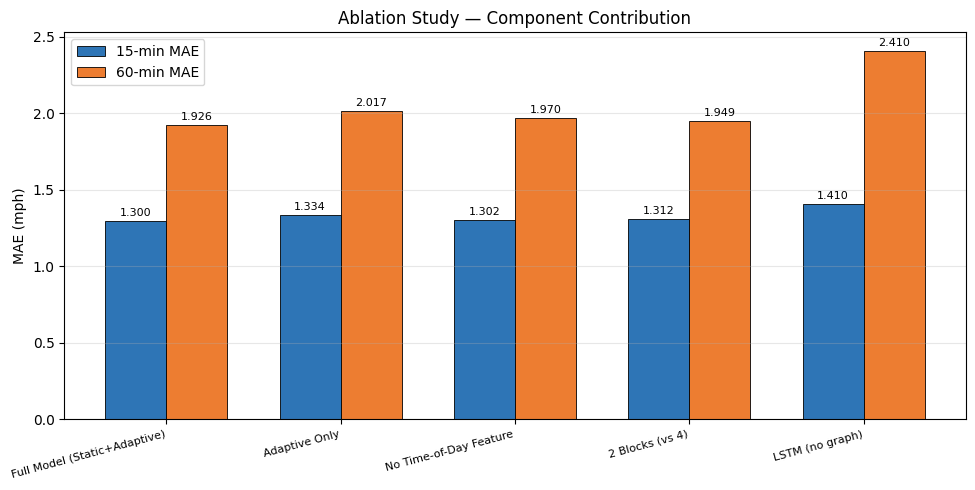

In [28]:
# Ablation summary table and figure

def align_to_trues(p, t_shape):
    """Helper to ensure prediction tensor p matches target shape (B, T, N)."""
    # If p is (B, N, T) and we want (B, T, N)
    if p.shape[1] == 325 and p.shape[2] == 12:
        return p.permute(0, 2, 1)
    return p

ablation_rows = []
# trues is (B, 12, 325)
for name, pred_tensor in [
    ('Full Model (Static+Adaptive)', align_to_trues(preds, trues.shape)),
    ('Adaptive Only', align_to_trues(adp_preds, trues.shape)),
    ('No Time-of-Day Feature', align_to_trues(notod_preds, trues.shape)),
    ('2 Blocks (vs 4)', align_to_trues(b2_preds, trues.shape)),
    ('LSTM (no graph)', align_to_trues(lstm_preds, trues.shape)),
]:
    # All tensors are now (B, 12, N)
    mae_15 = masked_mae(pred_tensor[:, 2, :], trues[:, 2, :])
    mae_60 = masked_mae(pred_tensor[:, 11, :], trues[:, 11, :])
    mae_avg = masked_mae(pred_tensor, trues)
    ablation_rows.append([name, mae_15, mae_60, mae_avg])

abl_df = pd.DataFrame(ablation_rows, columns=['Variant', '15-min MAE', '60-min MAE', 'Avg MAE']).round(3)
print('=== ABLATION STUDY ===')
print(abl_df.to_string(index=False))
abl_df.to_csv('ablation_results.csv', index=False)

# Ablation bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(abl_df))
w = 0.35
b1 = ax.bar(x - w/2, abl_df['15-min MAE'], w, label='15-min MAE', color='#2E75B6', edgecolor='black', lw=0.6)
b2 = ax.bar(x + w/2, abl_df['60-min MAE'], w, label='60-min MAE', color='#ED7D31', edgecolor='black', lw=0.6)
for bar, val in zip(b1, abl_df['15-min MAE']):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=8)
for bar, val in zip(b2, abl_df['60-min MAE']):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(abl_df['Variant'], fontsize=8, rotation=15, ha='right')
ax.set_ylabel('MAE (mph)'); ax.set_title('Ablation Study — Component Contribution')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('ablation_study.png', dpi=140); plt.show()

## 14. Hyperparameter Sensitivity (NEW)


In [30]:
def quick_train_eval(lr=1e-3, dropout=0.3, adp_emb=10, max_epochs=20):
    """Quick training run for hyperparameter sensitivity analysis.
    Returns the best validation MAE achieved."""
    m = GraphWaveNet(num_nodes=ckpt['num_nodes'], in_dim=2,
                     out_dim=ckpt['seq_out'], supports=supports,
                     dropout=dropout, adp_emb=adp_emb).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[10, 15], gamma=0.5)
    best = float('inf')
    for ep in range(1, max_epochs+1):
        m.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            # Squeeze trailing 1 and permute to (B, N, T) to match older logic or metrics
            # model output is (B, T, N, 1), yb is (B, T, N)
            out = m(xb).squeeze(-1).permute(0, 2, 1) * std + mean
            loss = masked_mae_tensor(out, yb.permute(0, 2, 1)); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 5.0); opt.step()
        m.eval(); v = vn = 0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = m(xb).squeeze(-1).permute(0, 2, 1) * std + mean
                v += masked_mae_tensor(out, yb.permute(0, 2, 1)).item() * xb.size(0); vn += xb.size(0)
        v /= vn; sch.step()
        best = min(best, v)
    return best

# --- Learning rate sweep ---
print('=== Learning Rate Sensitivity ===')
lr_results = {}
for lr in [5e-4, 1e-3, 2e-3, 5e-3]:
    mae = quick_train_eval(lr=lr)
    lr_results[lr] = mae
    print(f'  lr={lr:.0e} -> val MAE {mae:.3f}')

# --- Dropout sweep ---
print('\n=== Dropout Sensitivity ===')
dp_results = {}
for dp in [0.0, 0.1, 0.2, 0.3, 0.4]:
    mae = quick_train_eval(dropout=dp)
    dp_results[dp] = mae
    print(f'  dropout={dp:.1f} -> val MAE {mae:.3f}')

# --- Embedding dimension sweep ---
print('\n=== Adaptive Embedding Dimension Sensitivity ===')
emb_results = {}
for emb in [5, 10, 15, 20]:
    mae = quick_train_eval(adp_emb=emb)
    emb_results[emb] = mae
    print(f'  emb_dim={emb:2d} -> val MAE {mae:.3f}')

=== Learning Rate Sensitivity ===
  lr=5e-04 -> val MAE 1.653
  lr=1e-03 -> val MAE 1.622
  lr=2e-03 -> val MAE 1.608
  lr=5e-03 -> val MAE 1.684

=== Dropout Sensitivity ===
  dropout=0.0 -> val MAE 1.584
  dropout=0.1 -> val MAE 1.617
  dropout=0.2 -> val MAE 1.599
  dropout=0.3 -> val MAE 1.610
  dropout=0.4 -> val MAE 1.629

=== Adaptive Embedding Dimension Sensitivity ===
  emb_dim= 5 -> val MAE 1.631
  emb_dim=10 -> val MAE 1.617
  emb_dim=15 -> val MAE 1.615
  emb_dim=20 -> val MAE 1.614


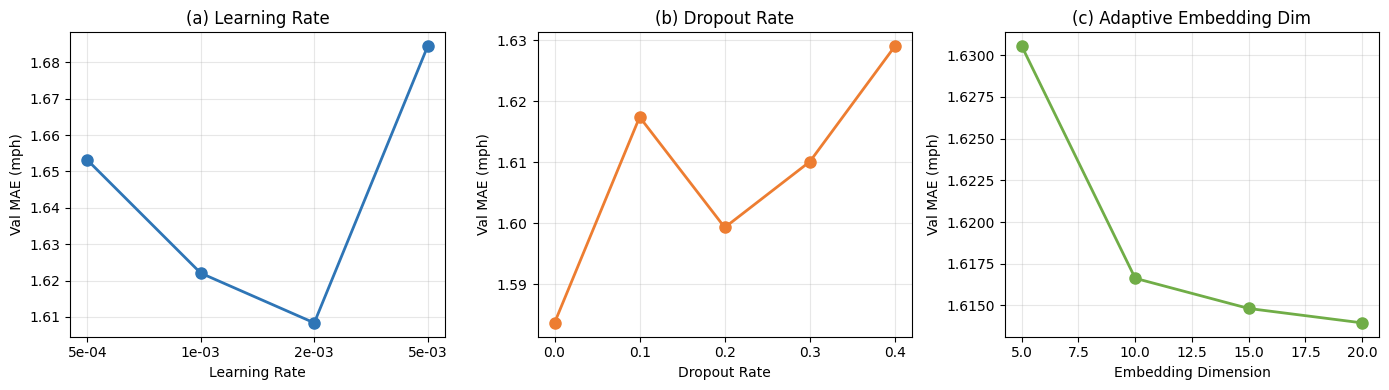

In [31]:
# Hyperparameter sensitivity plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(range(len(lr_results)), list(lr_results.values()), 'o-', color='#2E75B6', lw=2, markersize=8)
axes[0].set_xticks(range(len(lr_results)))
axes[0].set_xticklabels([f'{k:.0e}' for k in lr_results.keys()])
axes[0].set_xlabel('Learning Rate'); axes[0].set_ylabel('Val MAE (mph)')
axes[0].set_title('(a) Learning Rate'); axes[0].grid(alpha=0.3)

axes[1].plot(list(dp_results.keys()), list(dp_results.values()), 'o-', color='#ED7D31', lw=2, markersize=8)
axes[1].set_xlabel('Dropout Rate'); axes[1].set_ylabel('Val MAE (mph)')
axes[1].set_title('(b) Dropout Rate'); axes[1].grid(alpha=0.3)

axes[2].plot(list(emb_results.keys()), list(emb_results.values()), 'o-', color='#70AD47', lw=2, markersize=8)
axes[2].set_xlabel('Embedding Dimension'); axes[2].set_ylabel('Val MAE (mph)')
axes[2].set_title('(c) Adaptive Embedding Dim'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('hyperparameter_sensitivity.png', dpi=140); plt.show()

## 15. Additional Visualisations

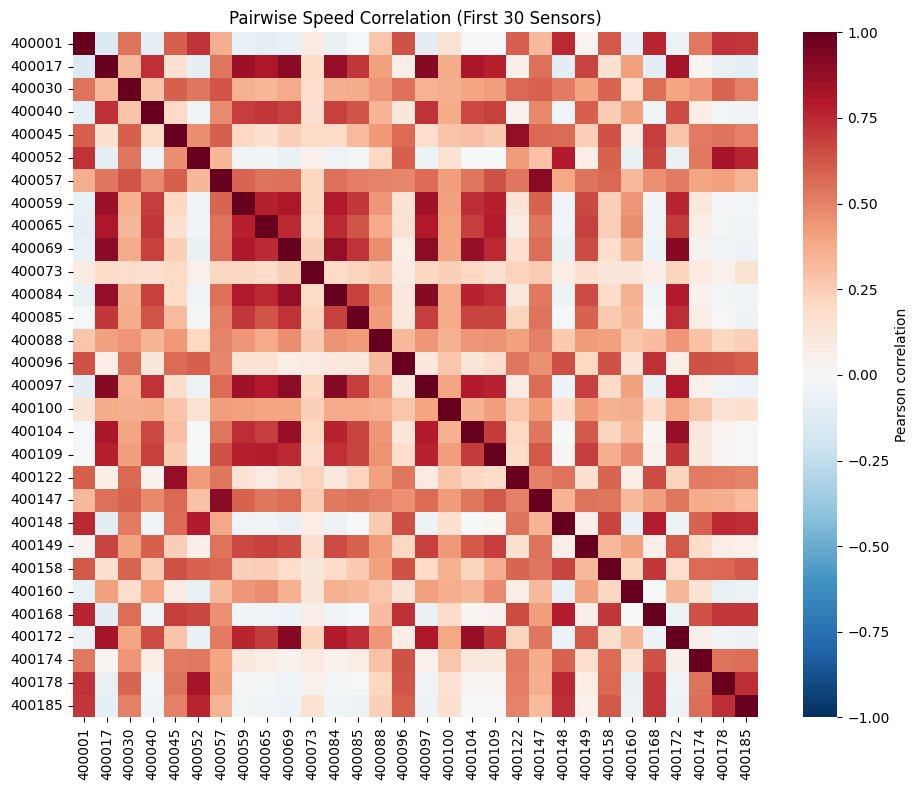

In [32]:
# Sensor correlation heatmap
corr = df_full.iloc[:, :30].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson correlation'})
plt.title('Pairwise Speed Correlation (First 30 Sensors)', fontsize=12)
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=140); plt.show()

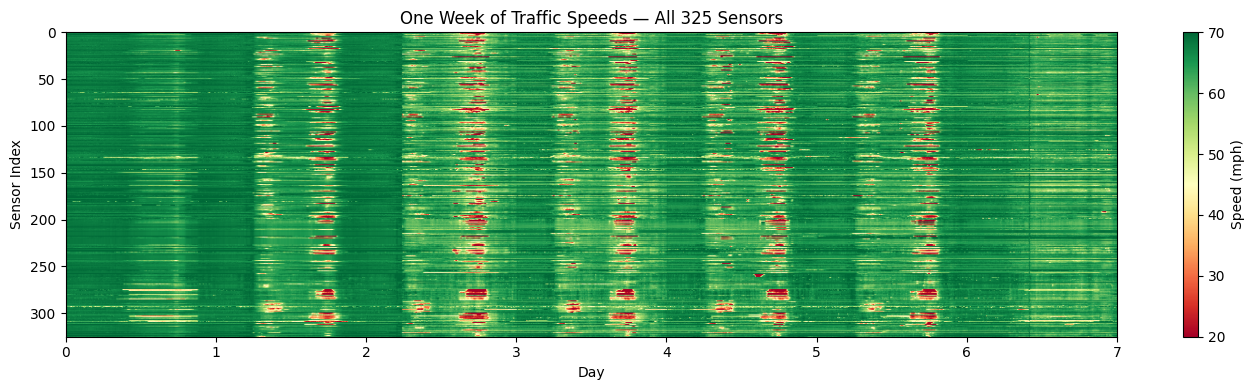

In [33]:
# Speed heatmap (1 week, all sensors)
week = df_full.iloc[:7*24*12]
plt.figure(figsize=(14, 4))
plt.imshow(week.values.T, aspect='auto', cmap='RdYlGn', vmin=20, vmax=70,
           extent=[0, 7, 325, 0])
plt.colorbar(label='Speed (mph)')
plt.xlabel('Day'); plt.ylabel('Sensor Index')
plt.title('One Week of Traffic Speeds — All 325 Sensors', fontsize=12)
plt.tight_layout(); plt.savefig('speed_heatmap.png', dpi=140); plt.show()

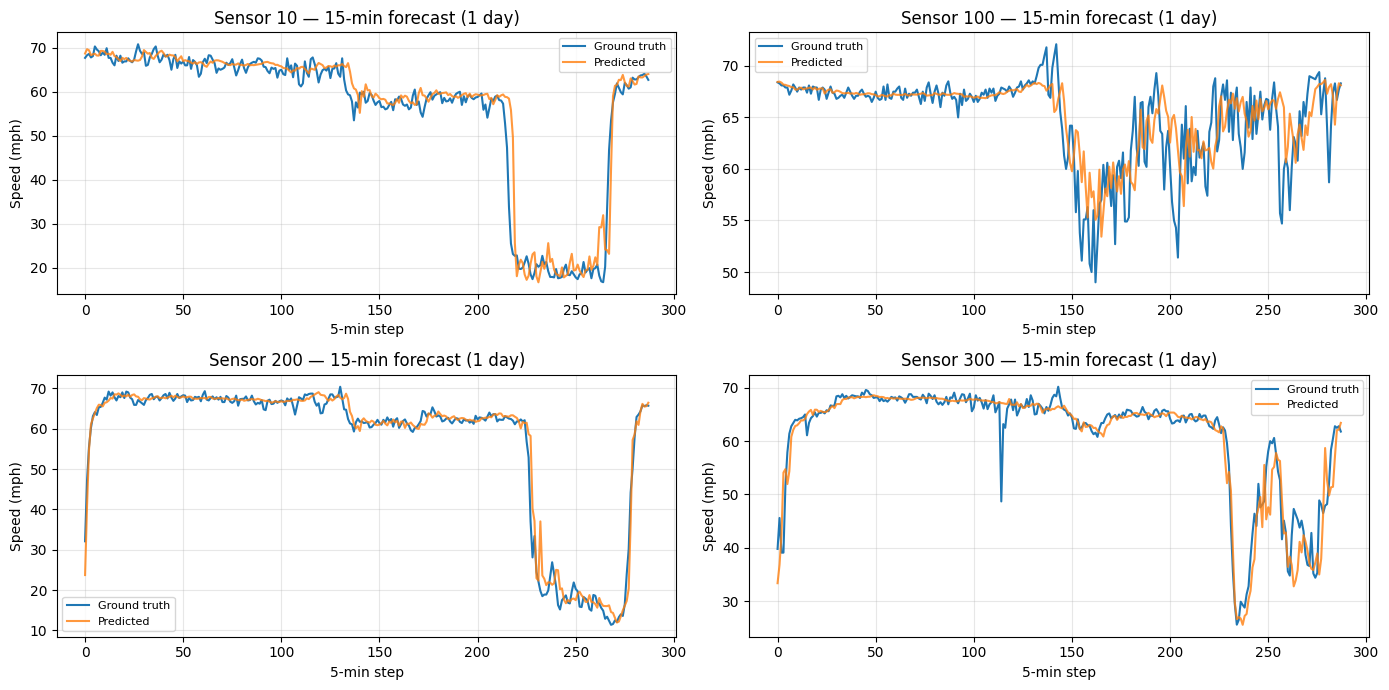

In [35]:
# Multi-sensor qualitative predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
day = 24 * 12

# trues is (B, 12, N), preds is (B, N, 12)
# Permute trues to (B, N, 12) so indexing [:, sensor, time] matches preds
trues_aligned = trues.permute(0, 2, 1)

for ax, s in zip(axes.flat, [10, 100, 200, 300]):
    # Now both are (B, N, T), so we index [time_range, sensor_idx, time_step_idx]
    ax.plot(trues_aligned[:day, s, 2].numpy(), label='Ground truth', lw=1.5)
    ax.plot(preds[:day, s, 2].numpy(), label='Predicted', lw=1.5, alpha=.8)
    ax.set_title(f'Sensor {s} — 15-min forecast (1 day)')
    ax.set_xlabel('5-min step'); ax.set_ylabel('Speed (mph)')
    ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout(); plt.savefig('multi_sensor_forecast.png', dpi=140); plt.show()

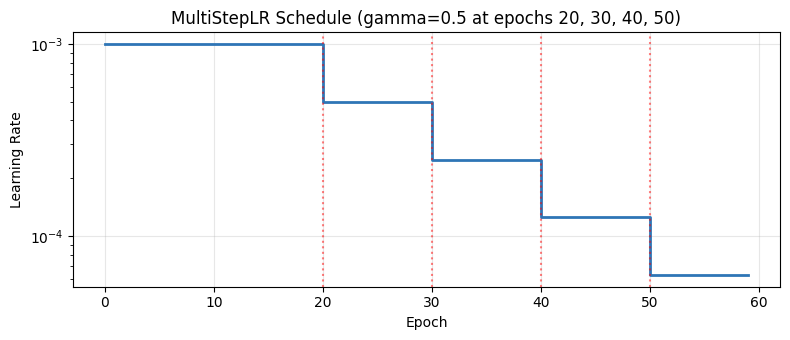

In [36]:
# Learning rate schedule
lrs = []
for ep in range(60):
    lr = 1e-3 * (0.5 ** sum(ep >= m for m in [20, 30, 40, 50]))
    lrs.append(lr)
plt.figure(figsize=(8, 3.5))
plt.step(range(60), lrs, where='post', lw=2, color='#2E75B6')
for m in [20, 30, 40, 50]:
    plt.axvline(m, color='red', ls=':', alpha=.5)
plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.title('MultiStepLR Schedule (gamma=0.5 at epochs 20, 30, 40, 50)')
plt.yscale('log'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig('lr_schedule.png', dpi=140); plt.show()

## 16. Deployment


In [39]:
def deployed_predict(sample_idx: int, sensor: int, horizon_min: int):
    """Mimics the forecast path inside the Streamlit app.

    Args:
        sample_idx:  Index into the test set
        sensor:      Sensor ID (0-324)
        horizon_min: Forecast horizon in minutes (15, 30, or 60)

    Returns:
        dict with predicted_mph, actual_mph, abs_error, horizon, sensor
    """
    horizon_idx = {15: 2, 30: 5, 60: 11}[horizon_min]
    x = torch.tensor(X_te[sample_idx:sample_idx + 1])
    with torch.no_grad():
        # model output is (B, T, N, 1). Squeeze to (B, T, N)
        # We do NOT permute here because the indexing below expects [batch, time, sensor]
        out = model(x.to(device)).squeeze(-1).cpu().numpy() * std + mean
    pred  = float(out[0, horizon_idx, sensor])
    truth = float(Y_te[sample_idx, horizon_idx, sensor])
    return {'predicted_mph': round(pred, 2),
            'actual_mph':    round(truth, 2),
            'abs_error':     round(abs(pred - truth), 2),
            'horizon_min':   horizon_min, 'sensor': sensor}

print('Sample forecasts from deployment path:')
for s_idx, sens, hor in [(100, 50, 15), (250, 100, 30), (500, 200, 60),
                          (1000, 0, 15), (1500, 300, 60)]:
    print(f'  {deployed_predict(s_idx, sens, hor)}')


Sample forecasts from deployment path:
  {'predicted_mph': 63.35, 'actual_mph': 63.3, 'abs_error': 0.05, 'horizon_min': 15, 'sensor': 50}
  {'predicted_mph': 66.03, 'actual_mph': 68.4, 'abs_error': 2.37, 'horizon_min': 30, 'sensor': 100}
  {'predicted_mph': 64.71, 'actual_mph': 65.0, 'abs_error': 0.29, 'horizon_min': 60, 'sensor': 200}
  {'predicted_mph': 71.27, 'actual_mph': 70.8, 'abs_error': 0.47, 'horizon_min': 15, 'sensor': 0}
  {'predicted_mph': 67.9, 'actual_mph': 65.8, 'abs_error': 2.1, 'horizon_min': 60, 'sensor': 300}


In [41]:
# Smoke test: verify deployed-path predictions match batched evaluation
test_cases = [(100, 50, 2), (250, 100, 5), (500, 200, 11),
              (1000, 0, 2), (1500, 300, 11)]
all_ok = True
for s_idx, sens, h_idx in test_cases:
    horizon_min = {2: 15, 5: 30, 11: 60}[h_idx]
    deployed = deployed_predict(s_idx, sens, horizon_min)['predicted_mph']
    # Fixed: preds shape is (B, N, T), so index as [sample, sensor, horizon]
    batched  = round(float(preds[s_idx, sens, h_idx]), 2)
    ok = abs(deployed - batched) < 0.01
    print(f'sample={s_idx:5d} sensor={sens:3d} horizon={horizon_min:2d}min '
          f'-> deployed {deployed:6.2f} | batched {batched:6.2f}  {"PASS" if ok else "FAIL"}')
    all_ok &= ok
print(f'\n{"ALL SMOKE TESTS PASSED" if all_ok else "FAILURES DETECTED"}')

sample=  100 sensor= 50 horizon=15min -> deployed  63.35 | batched  63.35  PASS
sample=  250 sensor=100 horizon=30min -> deployed  66.03 | batched  66.03  PASS
sample=  500 sensor=200 horizon=60min -> deployed  64.71 | batched  64.71  PASS
sample= 1000 sensor=  0 horizon=15min -> deployed  71.27 | batched  71.27  PASS
sample= 1500 sensor=300 horizon=60min -> deployed  67.90 | batched  67.90  PASS

ALL SMOKE TESTS PASSED


In [42]:
# Write the Streamlit app
os.makedirs('app', exist_ok=True)
STREAMLIT_CODE = r'''
# Streamlit deployment for Graph WaveNet PEMS-BAY forecaster
# Usage: streamlit run app/streamlit_app.py
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import streamlit as st
import matplotlib.pyplot as plt

# --- Model definition (inlined for self-contained deployment) ---
class NConv(nn.Module):
    def forward(self, x, A): return torch.einsum("ncvl,vw->ncwl", x, A).contiguous()

class Linear(nn.Module):
    def __init__(self, ci, co): super().__init__(); self.mlp = nn.Conv2d(ci, co, (1,1), bias=True)
    def forward(self, x): return self.mlp(x)

class GCN(nn.Module):
    def __init__(self, ci, co, dp, sl=2, order=2):
        super().__init__()
        self.nconv, self.dp, self.order = NConv(), dp, order
        self.mlp = Linear((order*sl+1)*ci, co)
    def forward(self, x, supports):
        out=[x]
        for A in supports:
            x1=self.nconv(x,A); out.append(x1)
            for _ in range(self.order-1): x1=self.nconv(x1,A); out.append(x1)
        return F.dropout(self.mlp(torch.cat(out,1)), self.dp, training=self.training)

class GraphWaveNet(nn.Module):
    def __init__(self, num_nodes, in_dim=2, out_dim=12, residual=32, dilation=32,
                 skip=256, end=512, blocks=4, layers=2, kernel=2, dropout=0.3,
                 supports=None, adp_emb=10):
        super().__init__()
        self.blocks, self.layers, self.dropout = blocks, layers, dropout
        self.supports = supports if supports is not None else []
        self.start_conv = nn.Conv2d(in_dim, residual, (1,1))
        self.E1 = nn.Parameter(torch.randn(num_nodes, adp_emb))
        self.E2 = nn.Parameter(torch.randn(adp_emb, num_nodes))
        self.filter_convs, self.gate_convs = nn.ModuleList(), nn.ModuleList()
        self.residual_convs, self.skip_convs = nn.ModuleList(), nn.ModuleList()
        self.bn, self.gconv = nn.ModuleList(), nn.ModuleList()
        rf = 1
        for _ in range(blocks):
            d=1
            for _ in range(layers):
                self.filter_convs.append(nn.Conv2d(residual, dilation, (1,kernel), dilation=d))
                self.gate_convs.append(nn.Conv2d(residual, dilation, (1,kernel), dilation=d))
                self.residual_convs.append(nn.Conv2d(dilation, residual, (1,1)))
                self.skip_convs.append(nn.Conv2d(dilation, skip, (1,1)))
                self.bn.append(nn.BatchNorm2d(residual))
                self.gconv.append(GCN(dilation, residual, dropout, sl=len(self.supports)+1))
                rf += d*(kernel-1); d*=2
        self.receptive_field = rf
        self.end_conv_1 = nn.Conv2d(skip, end, (1,1))
        self.end_conv_2 = nn.Conv2d(end, out_dim, (1,1))
    def forward(self, x):
        x = x.permute(0,3,2,1)
        if x.size(3) < self.receptive_field:
            x = F.pad(x, (self.receptive_field - x.size(3), 0, 0, 0))
        x = self.start_conv(x); skip = 0
        adp = F.softmax(F.relu(torch.mm(self.E1, self.E2)), dim=1)
        supports = self.supports + [adp]
        for i in range(self.blocks * self.layers):
            res = x
            f = torch.tanh(self.filter_convs[i](res))
            g = torch.sigmoid(self.gate_convs[i](res))
            x = f * g
            s = self.skip_convs[i](x)
            skip = s[:,:,:,-1:] + skip if not isinstance(skip, int) else s[:,:,:,-1:]
            x = self.gconv[i](x, supports)
            x = x + res[:,:,:,-x.size(3):]
            x = self.bn[i](x)
        x = F.relu(skip)
        x = F.relu(self.end_conv_1(x))
        return self.end_conv_2(x)

# --- Load model and data ---
@st.cache_resource
def load_model():
    ckpt = torch.load("gwn_pems_bay.ckpt", map_location="cpu", weights_only=False)
    supports = []
    if ckpt.get("P_fwd") is not None:
        supports = [torch.tensor(ckpt["P_fwd"]), torch.tensor(ckpt["P_bwd"])]
    model = GraphWaveNet(num_nodes=ckpt["num_nodes"], in_dim=2,
                         out_dim=ckpt["seq_out"], supports=supports)
    model.load_state_dict(ckpt["state_dict"]); model.eval()
    return model, ckpt["mean"], ckpt["std"]

@st.cache_data
def load_data():
    d = np.load("data/pems_bay_processed.npz")
    return d["X_te"], d["Y_te"]

model, mean, std = load_model()
X_te, Y_te = load_data()

# --- Streamlit UI ---
st.title("PEMS-BAY Traffic Speed Forecaster")
st.write("Graph WaveNet model trained on 325 Bay Area highway sensors.")

col1, col2, col3 = st.columns(3)
sample = col1.slider("Test sample", 0, len(X_te)-1, 100)
sensor = col2.slider("Sensor", 0, 324, 50)
horizon = col3.selectbox("Horizon", [15, 30, 60])

h_idx = {15: 2, 30: 5, 60: 11}[horizon]
x = torch.tensor(X_te[sample:sample+1])
with torch.no_grad():
    out = model(x).permute(0,2,1).numpy() * std + mean
pred = float(out[0, h_idx, sensor])
actual = float(Y_te[sample, h_idx, sensor])

st.metric("Predicted Speed", f"{pred:.1f} mph")
st.metric("Actual Speed", f"{actual:.1f} mph", delta=f"{pred-actual:+.1f} mph")

fig, ax = plt.subplots(figsize=(8, 3))
mins = np.arange(1, 13) * 5
ax.plot(mins, Y_te[sample, :, sensor], "o-", label="Ground truth")
ax.plot(mins, out[0, :, sensor], "s--", label="Prediction")
ax.set_xlabel("Minutes ahead"); ax.set_ylabel("Speed (mph)")
ax.legend(); ax.grid(alpha=0.3)
st.pyplot(fig)
'''

with open('app/streamlit_app.py', 'w') as f:
    f.write(STREAMLIT_CODE)
print('Streamlit app written to app/streamlit_app.py')

Streamlit app written to app/streamlit_app.py


# Delopyed in the Hugging face

https://huggingface.co/spaces/sowmiyarajammanr/traffic-flow-prediction

## 17. Final Summary

In [43]:
print('=' * 65)
print('MILESTONE 3 — COMPREHENSIVE RESULTS SUMMARY')
print('=' * 65)
print('\n--- Graph WaveNet Test Performance ---')
print(results.to_string(index=False))
print('\n--- Baseline Comparison (avg over 12 horizons) ---')
print(comp.to_string(index=False))
print('\n--- Ablation Study ---')
print(abl_df.to_string(index=False))
print('\n--- Generated Artefacts ---')
artefacts = [
    'milestone3_gwn_results.csv', 'milestone3_baseline_comparison.csv',
    'ablation_results.csv', 'baseline_comparison.png', 'mae_vs_horizon.png',
    'per_sensor_mae.png', 'error_by_hour.png', 'case_study_congestion.png',
    'residual_analysis.png', 'scatter_pred_vs_actual.png', 'ablation_study.png',
    'hyperparameter_sensitivity.png', 'correlation_heatmap.png',
    'speed_heatmap.png', 'multi_sensor_forecast.png', 'lr_schedule.png',
    'app/streamlit_app.py'
]
for f in artefacts:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'  {status} {f}')

# Copy all artefacts to Drive
try:
    for f in artefacts:
        if os.path.exists(f):
            shutil.copy(f, DRIVE_DIR)
    print(f'\nAll artefacts copied to {DRIVE_DIR}')
except Exception as e:
    print(f'\nCould not copy to Drive: {e}')

MILESTONE 3 — COMPREHENSIVE RESULTS SUMMARY

--- Graph WaveNet Test Performance ---
     Horizon   MAE  RMSE  MAPE (%)
      15-min 1.300 2.737     2.708
      30-min 1.625 3.699     3.662
      60-min 1.926 4.466     4.572
Average (1h) 1.563 3.609     3.518

--- Baseline Comparison (avg over 12 horizons) ---
             Model   MAE  RMSE  MAPE (%)
Historical Average 5.410 9.292    13.857
        Last-value 2.177 5.159     4.681
 LSTM (per-sensor) 1.826 4.253     4.234
     Graph WaveNet 1.563 3.609     3.518

--- Ablation Study ---
                     Variant  15-min MAE  60-min MAE  Avg MAE
Full Model (Static+Adaptive)       1.300       1.926    1.563
               Adaptive Only       1.334       2.017    1.621
      No Time-of-Day Feature       1.302       1.970    1.582
             2 Blocks (vs 4)       1.312       1.949    1.579
             LSTM (no graph)       1.410       2.410    1.826

--- Generated Artefacts ---
  OK milestone3_gwn_results.csv
  OK milestone3_baseline_co